<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy_of_copy_of_copy_of_gp__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# @title
!pip install google_play_scraper

In [32]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [34]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [35]:
all_reviews = []

for app_name, app_id in apps.items():
    print(f"Fetching reviews for {app_name}...")

    result, _ = reviews(
        app_id,
        lang="en",
        country="us",
        sort=Sort.NEWEST,
        count=3000
    )

    for r in result:
        all_reviews.append({
            "app_name": app_name,
            "review_text": r["content"],
            "rating": r["score"],
            "sentiment_label": label_sentiment(r["score"])
        })

Fetching reviews for Amazon...
Fetching reviews for Shein...
Fetching reviews for AliExpress...
Fetching reviews for Noon...
Fetching reviews for Trendyol...


In [36]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,That's not fair i've been a customer for a lon...,1,Negative
1,Amazon,THE AI TRASH HAS TO GO. NOW.,1,Negative
2,Amazon,New forced AI return feature doesn't work. can...,1,Negative
3,Amazon,how do you not have your app compatible with S...,1,Negative
4,Amazon,Often late. As in days... Frustrating. Oftenti...,2,Negative


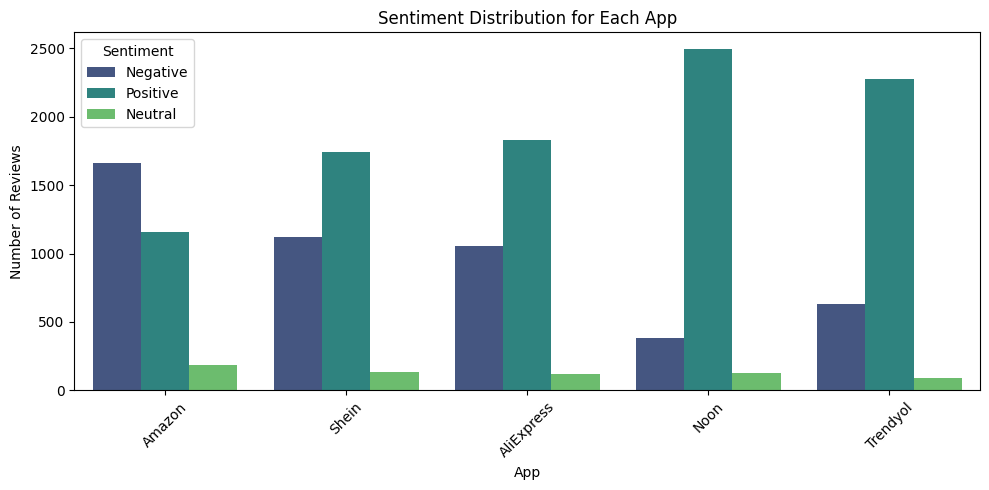

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [38]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    9498
Negative    4841
Neutral      661
Name: count, dtype: int64


In [39]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14439


In [40]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [41]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [42]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,That's not fair i've been a customer for a lon...,thats not fair ive been a customer for a long ...
1,THE AI TRASH HAS TO GO. NOW.,the ai trash has to go now
2,New forced AI return feature doesn't work. can...,new forced ai return feature doesnt work cant ...
3,how do you not have your app compatible with S...,how do you not have your app compatible with s...
4,Often late. As in days... Frustrating. Oftenti...,often late as in days frustrating oftentimes i...
5,They are trying to make me use WhatsApp.. very...,they are trying to make me use whatsapp very s...
6,brilliant thanks,brilliant thanks
7,I love scrolling on Amazon on my phone. Howeve...,i love scrolling on amazon on my phone however...
8,Amazon ok. just Hate Notification for products...,amazon ok just hate notification for products ...
9,I enjoy the comfort zone I am in..,i enjoy the comfort zone i am in


In [43]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [44]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,thats not fair ive been a customer for a long ...,"[thats, not, fair, ive, been, a, customer, for..."
1,the ai trash has to go now,"[the, ai, trash, has, to, go, now]"
2,new forced ai return feature doesnt work cant ...,"[new, forced, ai, return, feature, doesnt, wor..."
3,how do you not have your app compatible with s...,"[how, do, you, not, have, your, app, compatibl..."
4,often late as in days frustrating oftentimes i...,"[often, late, as, in, days, frustrating, often..."


In [45]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[thats, not, fair, ive, been, a, customer, for...","[thats, fair, ive, customer, long, time, said,...","[thats, fair, ive, customer, long, time, said,..."
1,"[the, ai, trash, has, to, go, now]","[ai, trash, go]","[ai, trash, go]"
2,"[new, forced, ai, return, feature, doesnt, wor...","[new, forced, ai, return, feature, doesnt, wor...","[new, forced, ai, return, feature, doesnt, wor..."
3,"[how, do, you, not, have, your, app, compatibl...","[app, compatible, samsung, tablets]","[app, compatible, samsung, tablet]"
4,"[often, late, as, in, days, frustrating, often...","[often, late, days, frustrating, oftentimes, o...","[often, late, day, frustrating, oftentimes, or..."


In [46]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

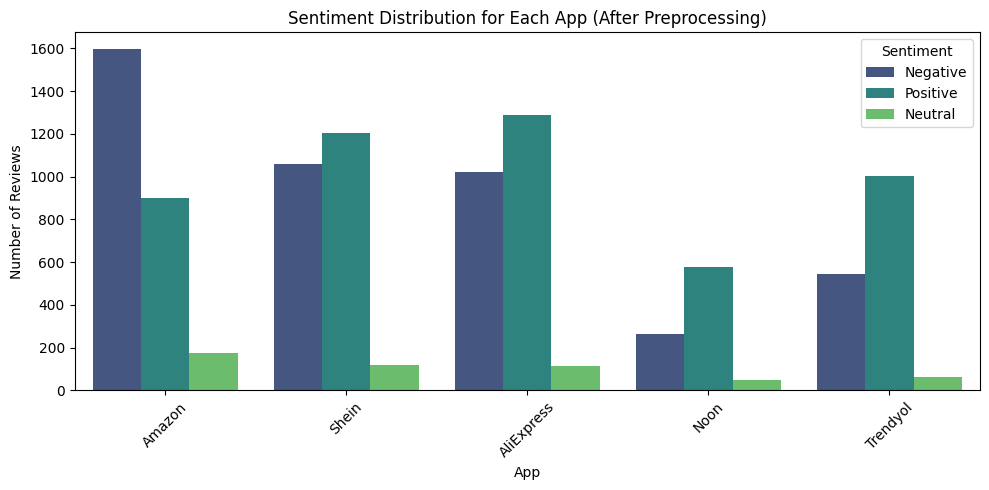

In [47]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [48]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    4964
Negative    4486
Neutral      518
Name: count, dtype: int64


In [49]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [50]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    3971
Negative    3589
Neutral      414
Name: count, dtype: int64
After SMOTE: sentiment_label
Negative    3971
Neutral     3971
Positive    3971
Name: count, dtype: int64


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 0.8079237713139418
Classification Report:
               precision    recall  f1-score   support

    Negative       0.79      0.86      0.82       897
     Neutral       0.17      0.08      0.11       104
    Positive       0.86      0.84      0.85       993

    accuracy                           0.81      1994
   macro avg       0.60      0.59      0.59      1994
weighted avg       0.79      0.81      0.80      1994

Confusion Matrix:
 [[772  17 108]
 [ 69   8  27]
 [139  23 831]]


In [54]:
from sklearn.tree import DecisionTreeClassifier



smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_balanced, y_train_balanced)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7417251755265798

Classification Report:

              precision    recall  f1-score   support

    Negative       0.76      0.76      0.76       897
     Neutral       0.11      0.15      0.13       104
    Positive       0.82      0.78      0.80       993

    accuracy                           0.74      1994
   macro avg       0.56      0.57      0.56      1994
weighted avg       0.76      0.74      0.75      1994

Confusion Matrix:
 [[684  76 137]
 [ 56  16  32]
 [160  54 779]]


In [55]:
# SUPPORT VECTOR MACHINE (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_balanced, y_train_balanced)

y_pred_SVM = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_SVM)

print("SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))


SVM Accuracy: 76.73 %

Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.80      0.83       897
     Neutral       0.09      0.24      0.13       104
    Positive       0.90      0.79      0.84       993

    accuracy                           0.77      1994
   macro avg       0.61      0.61      0.60      1994
weighted avg       0.83      0.77      0.80      1994

Confusion Matrix:
 [[722 110  65]
 [ 53  25  26]
 [ 76 134 783]]


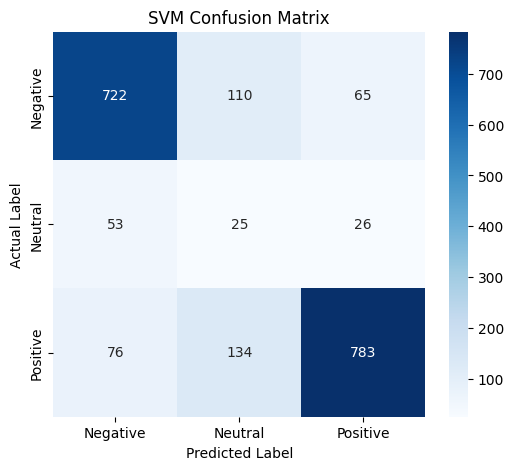

In [56]:

#  Confusion Matrix Graph FOR SVM

cm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [57]:
print(set(y_pred_SVM))

{'Neutral', 'Positive', 'Negative'}


In [58]:
from sklearn.naive_bayes import MultinomialNB


nb_model = MultinomialNB()


nb_model.fit(X_train_balanced, y_train_balanced)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7632898696088265

Classification Report:
               precision    recall  f1-score   support

    Negative       0.81      0.78      0.80       897
     Neutral       0.12      0.33      0.18       104
    Positive       0.93      0.79      0.85       993

    accuracy                           0.76      1994
   macro avg       0.62      0.63      0.61      1994
weighted avg       0.83      0.76      0.79      1994

Confusion Matrix:
 [[704 151  42]
 [ 54  34  16]
 [110  99 784]]


In [59]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train_encoded)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:35:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8044132397191575

Classification Report:

              precision    recall  f1-score   support

    Negative       0.83      0.81      0.82       897
     Neutral       0.15      0.16      0.15       104
    Positive       0.86      0.87      0.86       993

    accuracy                           0.80      1994
   macro avg       0.61      0.61      0.61      1994
weighted avg       0.81      0.80      0.81      1994

Confusion Matrix:

[[727  63 107]
 [ 56  17  31]
 [ 96  37 860]]
